# 02 — Lightweight ML Model Training (TensorFlow/Keras)
**Project:** Lightweight IDS for Raspberry Pi (SAG-DRDO Internship)  

This notebook trains a compact binary classifier for network intrusion detection using the artifacts generated in the previous step.

**Key design goals:**
- **< 10,000 parameters** (lightweight enough for Raspberry Pi with pruning)
- Architecture: small feed‑forward network (MLP) suitable for tabular flow features
- Uses `ReduceLROnPlateau`, `EarlyStopping`, and `ModelCheckpoint`
- Saves the trained model for later conversion to TensorFlow Lite

**What this notebook does:**
1. Loads preprocessed `X_train`, `y_train`, `X_test`, `y_test` from the `artifacts/` folder
2. Creates a 20% validation split from the training data
3. Builds & trains a lightweight MLP model (~5k parameters)
4. Evaluates and saves the final model to `artifacts/models/`

## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 300, 'axes.titlesize': 13})

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__} ✓")
print("All imports successful ✓")

TensorFlow version: 2.21.0 ✓
All imports successful ✓


## 2. Config & Paths

In [2]:
# ── CHANGE THESE to match your folder structure ───────────────────────────────
BASE_DIR      = "../"  # root of your project
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODEL_DIR     = os.path.join(ARTIFACTS_DIR, 'models')
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Models will be saved to: {MODEL_DIR} ✓')

Models will be saved to: ../artifacts\models ✓


## 3. Load Data & Create Validation Split

Notebook 01 saved `X_train.npy` and `X_test.npy`. We will load these and split the training data to create a validation set to monitor during training.

In [3]:
# Load arrays
X_train_full = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
y_train_full = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
X_test       = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy'))
y_test       = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

# Create an 80-20 train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y_train_full
)

input_dim = X_train.shape[1]

print('Data loaded and split successfully ✓\n')
print(f"Training samples   : {X_train.shape[0]:,} (Features: {input_dim})")
print(f"Validation samples : {X_val.shape[0]:,}")
print(f"Test samples       : {X_test.shape[0]:,}\n")
print(f"Class balance (train) : {np.mean(y_train)*100:.1f}% attack rate")
print(f"Class balance (val)   : {np.mean(y_val)*100:.1f}% attack rate")

Data loaded and split successfully ✓

Training samples   : 65,865 (Features: 36)
Validation samples : 16,467
Test samples       : 175,341

Class balance (train) : 55.1% attack rate
Class balance (val)   : 55.1% attack rate


## 4. Build a parameter‑efficient model

We use a compact MLP that stays **well below 10,000 parameters**. 

The formula for total parameters (Weights + Biases):
- Layer 1: `input_dim * h1 + h1`
- Layer 2: `h1 * h2 + h2`
- Layer 3: `h2 * h3 + h3`
- Output: `h3 * 1 + 1`

With our ANOVA-selected `input_dim=36` and `hidden_sizes=[64, 32, 16]`, the total is ≈ 2.4k + 2k + 0.5k = **~5,000** parameters. This is highly optimal for IoT edge devices.

In [4]:
def build_model(input_dim, hidden_sizes=[64, 32, 16], dropout=0.2):
    """Build a small MLP with Dropout."""
    model = keras.Sequential(name="IDS_Lightweight")
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(hidden_sizes):
        model.add(layers.Dense(units, activation='relu', name=f'dense_{i}'))
        model.add(layers.Dropout(dropout, name=f'dropout_{i}'))
    
    model.add(layers.Dense(1, activation='sigmoid', name='output'))
    return model

model = build_model(input_dim)
model.summary()

Model: "IDS_Lightweight"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (Dense)                 │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Verify total parameter count
total_params = model.count_params()
print(f"Total trainable parameters: {total_params:,}")
assert total_params < 10000, f"Model has {total_params} params – must be under 10000."
print("Parameter constraint satisfied ✓")

Total trainable parameters: 4,993
Parameter constraint satisfied ✓


## 5. Compile and configure callbacks

- **ModelCheckpoint**: saves the best weights based on validation loss.
- **EarlyStopping**: stops training when val loss stops improving.
- **ReduceLROnPlateau**: reduces LR dynamically when validation loss plateaus.

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]
print("Model compiled and callbacks configured ✓")

Model compiled and callbacks configured ✓


## 6. Train the model

In [7]:
BATCH_SIZE = 256
EPOCHS     = 100  # Early stopping will likely halt this earlier

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7153 - loss: 0.5206
Epoch 1: val_loss improved from None to 0.23004, saving model to ../artifacts\models\best_model.keras

Epoch 1: finished saving model to ../artifacts\models\best_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8081 - loss: 0.3912 - val_accuracy: 0.8944 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 2/100
255/258 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8843 - loss: 0.2510
Epoch 2: val_loss improved from 0.23004 to 0.18743, saving model to ../artifacts\models\best_model.keras

Epoch 2: finished saving model to ../artifacts\models\best_model.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8909 - loss: 0.2368 - val_accuracy: 0.9206 - val_loss: 0.1874 - learning_rate: 0.0010
Epoch 3/100
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9077 - loss: 0.2038
Epoch 3: val_loss improved from 0.18743 to 0.15879, saving model to ../artifacts\models\best_model.keras


## 7. Visualise training curves

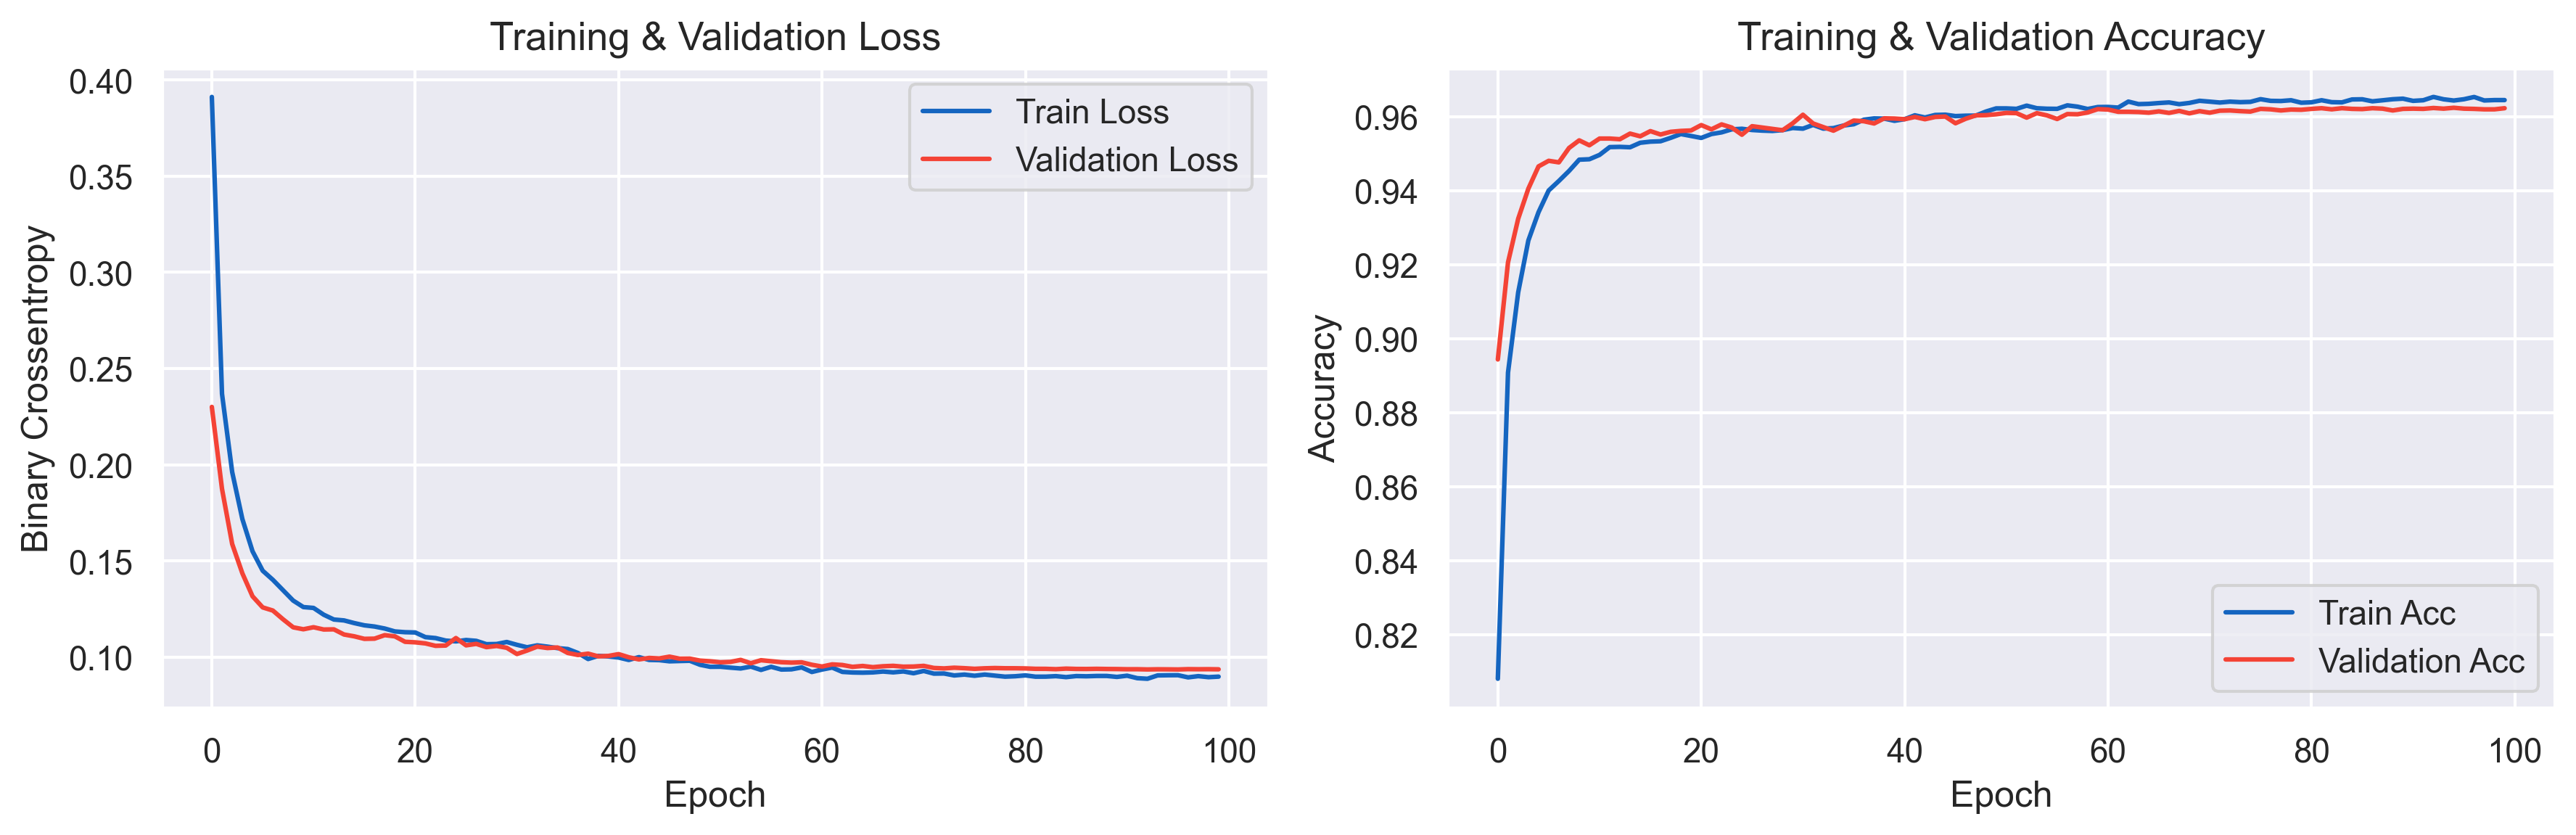

Training curves saved ✓


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss Plot
ax1.plot(history.history['loss'], label='Train Loss', color='#1565C0')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='#F44336')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Crossentropy')
ax1.legend()

# Accuracy Plot
ax2.plot(history.history['accuracy'], label='Train Acc', color='#1565C0')
ax2.plot(history.history['val_accuracy'], label='Validation Acc', color='#F44336')
ax2.set_title('Training & Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'training_curves.png'), bbox_inches='tight')
plt.show()
print('Training curves saved ✓')

## 8. Evaluate on the Unseen Test Set

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print("=" * 40)

  Test Loss     : 0.5057
  Test Accuracy : 89.05%


## 9. Save the Final Model

We save two formats inside the `artifacts/models` folder:
- Keras native format (`.keras`) – best for general inference and resuming training.
- HDF5 (`.h5`) – preferred by certain legacy TFLite conversion workflows.

In [10]:
model.save(os.path.join(MODEL_DIR, 'final_model.keras'))
model.save(os.path.join(MODEL_DIR, 'final_model.h5'))
print(f"Models saved successfully to {MODEL_DIR}/ ✓")
print("\nReady for next step: Pruning and Quantization (03_pruning_quantization.ipynb)")

Models saved successfully to ../artifacts\models/ ✓

Ready for next step: Pruning and Quantization (03_pruning_quantization.ipynb)
